<a href="https://colab.research.google.com/github/MohmmadSami/AI_Labs/blob/main/AI_Labtask_09(53199).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🤖 Lab Task 09 — K-Nearest Neighbors (KNN) Classifier
---
| Field | Details |
|-------|---------|
| **Name** | Mohammad Sami |
| **SAP ID** | 53199 |
| **Course** | Artificial Intelligence |
| **Instructor** | Mr. Junaid Khan |
| **Lab Task** | 09 |

---
## 📌 Objective
- Understand what KNN is and how it works
- Implement KNN from scratch (without using sklearn)
- Apply KNN on multiple datasets with different K values
- Compare accuracy across different configurations
- Visualize and analyze the results


---
## 📦 Section 0: Importing Required Libraries
> All necessary Python libraries are imported here before we begin any implementation.


In [1]:
# ============================================================
#   SECTION 0 — Import Libraries
#   Purpose : Load all tools needed for data handling,
#             modeling, evaluation, and visualization.
# ============================================================

# numpy  → numerical operations (arrays, math)
import numpy as np

# pandas → data loading and manipulation (DataFrames)
import pandas as pd

# matplotlib & seaborn → plotting graphs and heatmaps
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn datasets → built-in benchmark datasets for testing
from sklearn.datasets import load_iris, load_breast_cancer, make_classification

# train_test_split → splits data into training and testing sets
from sklearn.model_selection import train_test_split

# KNeighborsClassifier → sklearn's ready-made KNN implementation
from sklearn.neighbors import KNeighborsClassifier

# StandardScaler → normalizes features to same scale (important for KNN!)
from sklearn.preprocessing import StandardScaler

# Evaluation tools → measure how well the model performs
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# mode → finds the most common value (used for majority vote in custom KNN)
from scipy.stats import mode

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


---
## 📖 Section 1: Theory — How KNN Works

**KNN (K-Nearest Neighbors)** is a simple supervised classification algorithm.

### 🔑 Key Concepts:
| Concept | Explanation |
|---------|-------------|
| Non-parametric | Makes no assumptions about data distribution |
| Lazy learner | No training phase — all data is stored and used at prediction time |
| K | Number of nearest neighbors to consider for voting |
| Distance metric | Euclidean distance is used to find neighbors |

### 🔢 Euclidean Distance Formula:
$$d(a,b) = \sqrt{\sum_{j=1}^{n}(x_j^a - x_j^b)^2}$$

### 🔄 Algorithm Steps:
1. Store all training examples
2. For each test point, calculate distance to all training points
3. Pick the K nearest training points
4. Assign the most common class among those K points as the prediction


---
## 🔧 Section 2: Custom KNN Implementation (From Scratch)
> Here we build the KNN algorithm manually — no sklearn — to understand the internal mechanics step by step.


In [2]:
# ============================================================
#   SECTION 2 — Custom KNN Classifier (Built From Scratch)
#
#   WHY build from scratch?
#   → To understand exactly what happens under the hood:
#     distance calculation, neighbor selection, and voting.
# ============================================================

class K_Nearest_Neighbors_Classifier:
    """
    A hand-built KNN classifier using Euclidean distance.
    Mimics sklearn's KNeighborsClassifier for learning purposes.
    """

    def __init__(self, K):
        """
        Constructor: called when we create the classifier object.

        Parameter:
            K (int) → how many neighbors to look at when classifying

        Example: model = K_Nearest_Neighbors_Classifier(K=3)
        """
        self.K = K  # Store K so all methods can access it

    # ----------------------------------------------------------
    # FIT — Store training data (KNN doesn't actually "train")
    # ----------------------------------------------------------
    def fit(self, X_train, Y_train):
        """
        Stores the training data.
        KNN is a LAZY LEARNER — it skips the training phase
        and simply memorizes all examples for later use.

        Parameters:
            X_train → 2D array of feature vectors (one row per sample)
            Y_train → 1D array of class labels (one per sample)
        """
        self.X_train = X_train          # Save feature matrix
        self.Y_train = Y_train          # Save label array
        self.m, self.n = X_train.shape  # m = num samples, n = num features

    # ----------------------------------------------------------
    # PREDICT — Classify every test point
    # ----------------------------------------------------------
    def predict(self, X_test):
        """
        Predicts the class label for each test example.

        Workflow per test point:
          1. Find the K nearest training neighbors
          2. Collect their labels
          3. Return the most frequent label (majority vote)
        """
        # Create an empty array to hold predictions
        Y_pred = np.zeros(len(X_test), dtype=int)

        for i, x in enumerate(X_test):
            # Step 1: Get the labels of the K closest neighbors
            neighbors = self.find_neighbors(x)

            # Step 2: Majority vote — whichever class appears most often wins
            Y_pred[i] = mode(neighbors, keepdims=True).mode[0]

        return Y_pred

    # ----------------------------------------------------------
    # FIND NEIGHBORS — Locate the K closest training points
    # ----------------------------------------------------------
    def find_neighbors(self, x):
        """
        Finds K training examples closest to test point x.

        Steps:
          1. Compute Euclidean distance from x to every training point
          2. Sort all training labels by that distance (closest first)
          3. Return only the first K labels
        """
        # Compute distance from test point x to EVERY training point
        euclidean_distances = np.array([
            self.euclidean(x, self.X_train[i]) for i in range(self.m)
        ])

        # argsort() returns indices that would sort the array (ascending)
        inds = euclidean_distances.argsort()

        # Reorder labels by distance (nearest neighbor first)
        Y_train_sorted = self.Y_train[inds]

        # Return only the K closest neighbors' labels
        return Y_train_sorted[:self.K]

    # ----------------------------------------------------------
    # EUCLIDEAN — Compute distance between two points
    # ----------------------------------------------------------
    def euclidean(self, x, x_train):
        """
        Euclidean distance formula:
            d = sqrt( sum( (x_i - x_train_i)^2 ) )

        This measures how 'far apart' two data points are
        in n-dimensional feature space.
        """
        return np.sqrt(np.sum(np.square(x - x_train)))


print("✅ Custom KNN class defined successfully!")
print("   Methods: __init__ | fit | predict | find_neighbors | euclidean")


✅ Custom KNN class defined successfully!
   Methods: __init__ | fit | predict | find_neighbors | euclidean


---
## 🌸 Section 3: Dataset 1 — Iris Dataset
> **About:** 150 flower samples, 4 features (sepal/petal dimensions), 3 classes.  
> **Goal:** Test our custom KNN vs sklearn KNN across different K values.


In [3]:
# ============================================================
#   SECTION 3 — KNN on the Iris Dataset
#
#   Dataset Info:
#     • 150 samples (flowers)
#     • 4 features: sepal length, sepal width, petal length, petal width
#     • 3 classes: Setosa (0), Versicolor (1), Virginica (2)
# ============================================================

# ── Step 1: Load the dataset ──────────────────────────────
iris = load_iris()
X_iris = iris.data    # Feature matrix (150 x 4)
Y_iris = iris.target  # Labels (0, 1, or 2)

print(f"Dataset shape  : {X_iris.shape}")
print(f"Classes        : {list(iris.target_names)}")
print(f"Samples/class  : {dict(zip(iris.target_names, np.bincount(Y_iris)))}")

# ── Step 2: Feature Scaling ───────────────────────────────
# WHY scale? KNN uses distances — if one feature has large values
# (e.g., 0–800) and another small (0–1), the large one dominates.
# StandardScaler converts each feature to mean=0, std=1.
scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(X_iris)

# ── Step 3: Train/Test Split ──────────────────────────────
# 70% of data used to train (store), 30% used to test
X_train_iris, X_test_iris, Y_train_iris, Y_test_iris = train_test_split(
    X_iris_scaled, Y_iris,
    test_size=0.3,      # 30% goes to test set
    random_state=42     # Fixed seed → reproducible results
)

print(f"\nTraining samples : {X_train_iris.shape[0]}")
print(f"Test samples     : {X_test_iris.shape[0]}")

# ── Step 4: Test Multiple K Values ───────────────────────
# We try K = 1, 3, 5, 7, 9, 11, 15
# Small K  → very sensitive to noise (overfitting risk)
# Large K  → smoother boundary but may underfit
k_values = [1, 3, 5, 7, 9, 11, 15]

iris_accuracies_custom  = []   # Store results from our custom model
iris_accuracies_sklearn = []   # Store results from sklearn model

print("\n" + "─"*55)
print(f"{'K':>4}  {'Custom KNN':>12}  {'Sklearn KNN':>12}")
print("─"*55)

for k in k_values:
    # --- Our Custom KNN ---
    custom_knn = K_Nearest_Neighbors_Classifier(K=k)
    custom_knn.fit(X_train_iris, Y_train_iris)           # Memorize training data
    y_pred_custom = custom_knn.predict(X_test_iris)      # Classify test points
    acc_custom = accuracy_score(Y_test_iris, y_pred_custom) * 100
    iris_accuracies_custom.append(acc_custom)

    # --- Sklearn's KNN (for cross-validation / sanity check) ---
    sk_knn = KNeighborsClassifier(n_neighbors=k)
    sk_knn.fit(X_train_iris, Y_train_iris)
    y_pred_sk = sk_knn.predict(X_test_iris)
    acc_sk = accuracy_score(Y_test_iris, y_pred_sk) * 100
    iris_accuracies_sklearn.append(acc_sk)

    print(f"  K={k:<3}  {acc_custom:>10.2f}%  {acc_sk:>10.2f}%")

# ── Step 5: Find the Best K ───────────────────────────────
best_k_iris = k_values[np.argmax(iris_accuracies_sklearn)]
print("─"*55)
print(f"\n🏆 Best K for Iris: {best_k_iris}  →  Accuracy: {max(iris_accuracies_sklearn):.2f}%")


Dataset shape  : (150, 4)
Classes        : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
Samples/class  : {np.str_('setosa'): np.int64(50), np.str_('versicolor'): np.int64(50), np.str_('virginica'): np.int64(50)}

Training samples : 105
Test samples     : 45

───────────────────────────────────────────────────────
   K    Custom KNN   Sklearn KNN
───────────────────────────────────────────────────────
  K=1         97.78%       97.78%
  K=3        100.00%      100.00%
  K=5        100.00%      100.00%
  K=7        100.00%      100.00%
  K=9        100.00%      100.00%
  K=11       100.00%      100.00%
  K=15       100.00%      100.00%
───────────────────────────────────────────────────────

🏆 Best K for Iris: 3  →  Accuracy: 100.00%


/tmp/ipykernel_3127/1912895688.py:29: UserWarning: Glyph 127800 (\N{CHERRY BLOSSOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127800 (\N{CHERRY BLOSSOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


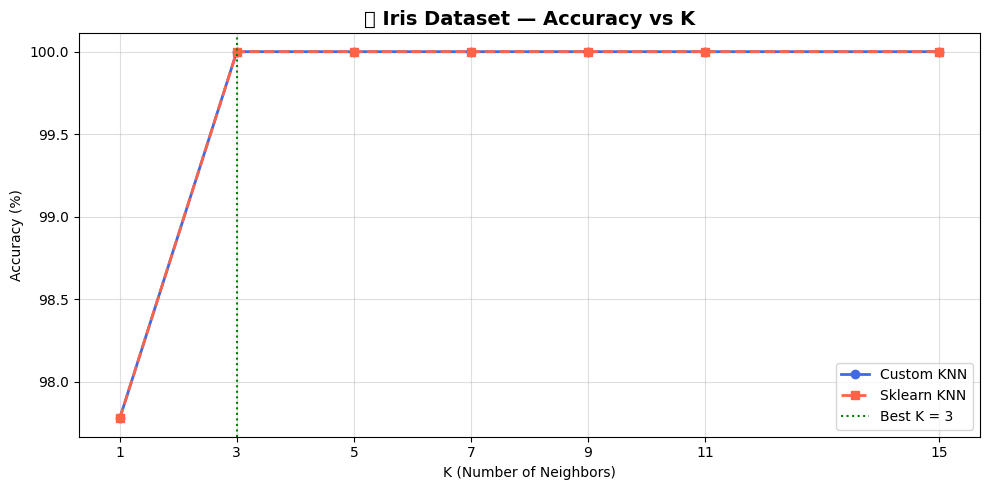

In [4]:
# ============================================================
#   SECTION 3 — Plot: Accuracy vs K (Iris Dataset)
#
#   This graph helps us visually identify the optimal K.
#   We plot both Custom KNN and Sklearn KNN to confirm
#   our implementation is correct (lines should overlap).
# ============================================================

plt.figure(figsize=(10, 5))

# Plot custom KNN accuracy line
plt.plot(k_values, iris_accuracies_custom,
         marker='o', label='Custom KNN',  color='royalblue', linewidth=2)

# Plot sklearn KNN accuracy line (dashed for comparison)
plt.plot(k_values, iris_accuracies_sklearn,
         marker='s', label='Sklearn KNN', color='tomato',    linewidth=2, linestyle='--')

# Mark the best K with a vertical dashed line
plt.axvline(x=best_k_iris, color='green', linestyle=':', linewidth=1.5,
            label=f'Best K = {best_k_iris}')

plt.title('🌸 Iris Dataset — Accuracy vs K', fontsize=14, fontweight='bold')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Accuracy (%)')
plt.xticks(k_values)
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


---
## 🩺 Section 4: Dataset 2 — Breast Cancer Dataset
> **About:** 569 patient records, 30 features (tumor measurements), 2 classes (Malignant / Benign).  
> **Goal:** See how KNN handles a high-dimensional medical dataset.


In [5]:
# ============================================================
#   SECTION 4 — KNN on the Breast Cancer Dataset
#
#   Dataset Info:
#     • 569 samples (patients)
#     • 30 features: tumor size, texture, perimeter, area, etc.
#     • 2 classes: Malignant (0) = cancerous, Benign (1) = non-cancerous
#
#   This is a REAL medical dataset — accuracy here matters!
# ============================================================

# ── Step 1: Load dataset ──────────────────────────────────
cancer = load_breast_cancer()
X_cancer = cancer.data    # 569 x 30 feature matrix
Y_cancer = cancer.target  # 0 = malignant, 1 = benign

print(f"Dataset shape    : {X_cancer.shape}")
print(f"Classes          : {list(cancer.target_names)}")
print(f"Samples/class    : Malignant={np.sum(Y_cancer==0)}, Benign={np.sum(Y_cancer==1)}")

# ── Step 2: Scale features ────────────────────────────────
# Even more critical here — 30 features with very different ranges
scaler2 = StandardScaler()
X_cancer_scaled = scaler2.fit_transform(X_cancer)

# ── Step 3: 70/30 split ───────────────────────────────────
X_train_c, X_test_c, Y_train_c, Y_test_c = train_test_split(
    X_cancer_scaled, Y_cancer,
    test_size=0.3,
    random_state=42
)

print(f"\nTraining samples : {X_train_c.shape[0]}")
print(f"Test samples     : {X_test_c.shape[0]}")

# ── Step 4: Test multiple K values using sklearn KNN ─────
# (Custom KNN would be slow on 569 × 30 data, so using sklearn here)
cancer_accuracies = []

print("\n" + "─"*35)
print(f"{'K':>4}  {'Accuracy':>12}")
print("─"*35)

for k in k_values:
    sk_knn = KNeighborsClassifier(n_neighbors=k)
    sk_knn.fit(X_train_c, Y_train_c)

    # Predict labels for all test samples
    y_pred = sk_knn.predict(X_test_c)

    # Calculate what % of predictions were correct
    acc = accuracy_score(Y_test_c, y_pred) * 100
    cancer_accuracies.append(acc)
    print(f"  K={k:<3}  {acc:>10.2f}%")

# ── Step 5: Identify best K ───────────────────────────────
best_k_cancer = k_values[np.argmax(cancer_accuracies)]
print("─"*35)
print(f"\n🏆 Best K for Breast Cancer: {best_k_cancer}  →  Accuracy: {max(cancer_accuracies):.2f}%")


Dataset shape    : (569, 30)
Classes          : [np.str_('malignant'), np.str_('benign')]
Samples/class    : Malignant=212, Benign=357

Training samples : 398
Test samples     : 171

───────────────────────────────────
   K      Accuracy
───────────────────────────────────
  K=1         95.32%
  K=3         95.91%
  K=5         95.91%
  K=7         95.91%
  K=9         97.08%
  K=11        95.91%
  K=15        95.32%
───────────────────────────────────

🏆 Best K for Breast Cancer: 9  →  Accuracy: 97.08%


---
## 🧪 Section 5: Dataset 3 — Synthetic Dataset (Custom Distribution)
> **About:** Artificially generated dataset where we control samples, features, classes, and cluster spread.  
> **Goal:** Explore how changing data distribution affects KNN accuracy.


In [6]:
# ============================================================
#   SECTION 5 — KNN on a Synthetic (Custom) Dataset
#
#   Using make_classification we can control:
#     • n_samples    → total number of data points
#     • n_features   → number of input features
#     • n_classes    → number of output classes
#     • class_sep    → how spread apart the clusters are
#                      (higher = easier to classify)
#
#   This satisfies the lab requirement:
#   "Change number of samples, characteristics, classes,
#    and distribution of each cluster"
# ============================================================

# ── Step 1: Generate Synthetic Dataset ───────────────────
X_syn, Y_syn = make_classification(
    n_samples=500,           # 500 data points total
    n_features=5,            # 5 input features
    n_informative=4,         # 4 of them are actually useful
    n_redundant=1,           # 1 is a noisy combination of others
    n_classes=3,             # 3 output classes
    n_clusters_per_class=1,  # 1 tight cluster per class
    class_sep=1.5,           # Medium separation between classes
    random_state=42
)

print(f"Synthetic Dataset Shape : {X_syn.shape}")
print(f"Samples per class       : {dict(enumerate(np.bincount(Y_syn)))}")
print(f"  (0 → Class A, 1 → Class B, 2 → Class C)")

# ── Step 2: Scale features ────────────────────────────────
scaler3 = StandardScaler()
X_syn_scaled = scaler3.fit_transform(X_syn)

# ── Step 3: Train/Test Split ──────────────────────────────
X_train_s, X_test_s, Y_train_s, Y_test_s = train_test_split(
    X_syn_scaled, Y_syn,
    test_size=0.3,
    random_state=42
)

# ── Step 4: Test multiple K values ───────────────────────
syn_accuracies = []

print("\n" + "─"*35)
print(f"{'K':>4}  {'Accuracy':>12}")
print("─"*35)

for k in k_values:
    sk_knn = KNeighborsClassifier(n_neighbors=k)
    sk_knn.fit(X_train_s, Y_train_s)
    acc = accuracy_score(Y_test_s, sk_knn.predict(X_test_s)) * 100
    syn_accuracies.append(acc)
    print(f"  K={k:<3}  {acc:>10.2f}%")

best_k_syn = k_values[np.argmax(syn_accuracies)]
print("─"*35)
print(f"\n🏆 Best K for Synthetic: {best_k_syn}  →  Accuracy: {max(syn_accuracies):.2f}%")


Synthetic Dataset Shape : (500, 5)
Samples per class       : {0: np.int64(168), 1: np.int64(166), 2: np.int64(166)}
  (0 → Class A, 1 → Class B, 2 → Class C)

───────────────────────────────────
   K      Accuracy
───────────────────────────────────
  K=1         86.00%
  K=3         89.33%
  K=5         88.67%
  K=7         90.00%
  K=9         88.00%
  K=11        88.67%
  K=15        90.00%
───────────────────────────────────

🏆 Best K for Synthetic: 7  →  Accuracy: 90.00%


---
## 📊 Section 6: Comparison — All Datasets vs All K Values
> Here we bring all results together to compare performance across datasets and identify trends.


/tmp/ipykernel_3127/1322209936.py:26: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3127/1322209936.py:26: UserWarning: Glyph 127800 (\N{CHERRY BLOSSOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3127/1322209936.py:26: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3127/1322209936.py:26: UserWarning: Glyph 129514 (\N{TEST TUBE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127800 (\N{CHERRY BLOSSOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:1

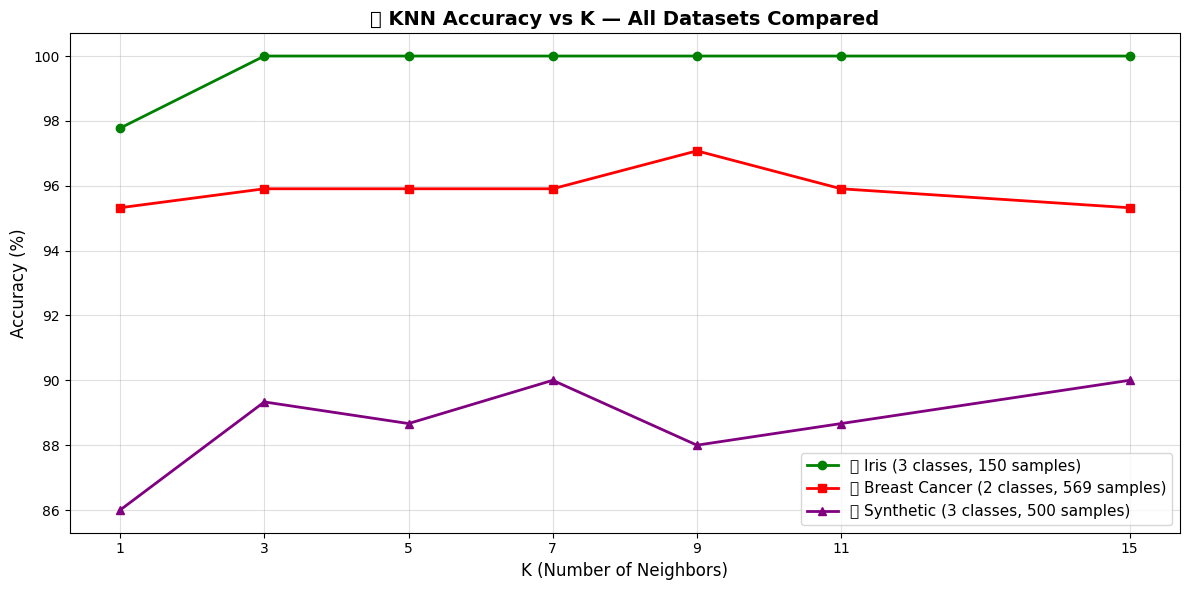


  Dataset                Best K     Best Accuracy
  Iris                   3          100.00%
  Breast Cancer          9          97.08%
  Synthetic              7          90.00%


In [7]:
# ============================================================
#   SECTION 6 — Comparison Plot: All Datasets Together
#
#   Why compare?
#   → Different datasets respond differently to K.
#   → A good K for one dataset may be bad for another.
#   → Comparison shows how dataset complexity affects KNN.
# ============================================================

plt.figure(figsize=(12, 6))

# Each dataset gets its own line on the same graph
plt.plot(k_values, iris_accuracies_sklearn,
         marker='o', label='🌸 Iris (3 classes, 150 samples)',          color='green',  linewidth=2)
plt.plot(k_values, cancer_accuracies,
         marker='s', label='🩺 Breast Cancer (2 classes, 569 samples)', color='red',    linewidth=2)
plt.plot(k_values, syn_accuracies,
         marker='^', label='🧪 Synthetic (3 classes, 500 samples)',     color='purple', linewidth=2)

plt.title('📊 KNN Accuracy vs K — All Datasets Compared', fontsize=14, fontweight='bold')
plt.xlabel('K (Number of Neighbors)', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.xticks(k_values)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# ── Summary Table ─────────────────────────────────────────
print("\n" + "="*60)
print(f"  {'Dataset':<22} {'Best K':<10} {'Best Accuracy'}")
print("="*60)
print(f"  {'Iris':<22} {best_k_iris:<10} {max(iris_accuracies_sklearn):.2f}%")
print(f"  {'Breast Cancer':<22} {best_k_cancer:<10} {max(cancer_accuracies):.2f}%")
print(f"  {'Synthetic':<22} {best_k_syn:<10} {max(syn_accuracies):.2f}%")
print("="*60)


---
## 📋 Section 7: Detailed Report — Best Model Analysis
> We pick the best-performing model and examine it in detail using a Classification Report and Confusion Matrix.


📋 Classification Report — Breast Cancer Dataset
   (Using best K = 9)
              precision    recall  f1-score   support

   malignant       0.97      0.95      0.96        63
      benign       0.97      0.98      0.98       108

    accuracy                           0.97       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.97      0.97      0.97       171



/tmp/ipykernel_3127/1124565503.py:42: UserWarning: Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


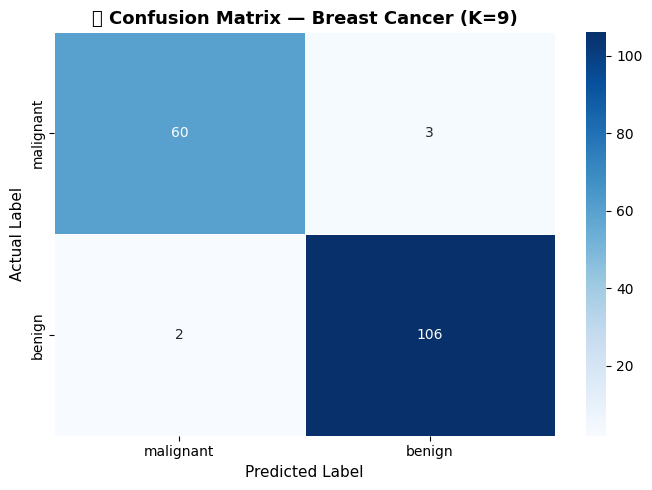


True Positives (correctly predicted Benign)    : 106
True Negatives (correctly predicted Malignant) : 60
False Positives (Malignant predicted as Benign): 3
False Negatives (Benign predicted as Malignant): 2


In [8]:
# ============================================================
#   SECTION 7 — Detailed Evaluation of the Best Model
#
#   We use the Breast Cancer dataset with the best K
#   and look at:
#     • Classification Report → precision, recall, F1 per class
#     • Confusion Matrix      → see exactly which classes get confused
#
#   Precision = of all predicted positives, how many were right?
#   Recall    = of all actual positives, how many did we catch?
#   F1-Score  = balanced average of precision and recall
# ============================================================

# ── Step 1: Train the best model ─────────────────────────
best_model = KNeighborsClassifier(n_neighbors=best_k_cancer)
best_model.fit(X_train_c, Y_train_c)

# ── Step 2: Predict on test set ───────────────────────────
Y_pred_best = best_model.predict(X_test_c)

# ── Step 3: Print Classification Report ──────────────────
print("📋 Classification Report — Breast Cancer Dataset")
print(f"   (Using best K = {best_k_cancer})")
print("="*55)
print(classification_report(Y_test_c, Y_pred_best,
                             target_names=cancer.target_names))

# ── Step 4: Confusion Matrix Heatmap ─────────────────────
# Rows = actual class, Columns = predicted class
# Diagonal = correct predictions, Off-diagonal = mistakes
cm = confusion_matrix(Y_test_c, Y_pred_best)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=cancer.target_names,
            yticklabels=cancer.target_names,
            linewidths=0.5)

plt.title(f'🔢 Confusion Matrix — Breast Cancer (K={best_k_cancer})', fontsize=13, fontweight='bold')
plt.ylabel('Actual Label',    fontsize=11)
plt.xlabel('Predicted Label', fontsize=11)
plt.tight_layout()
plt.show()

# Quick interpretation
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Positives (correctly predicted Benign)    : {tp}")
print(f"True Negatives (correctly predicted Malignant) : {tn}")
print(f"False Positives (Malignant predicted as Benign): {fp}")
print(f"False Negatives (Benign predicted as Malignant): {fn}")


---
## 🔬 Section 8: Effect of Changing Cluster Distribution
> The lab requires exploring how changing class separation affects performance. Here we test 3 distributions.


Low Separation (0.5)           → Best accuracy: 72.00% at K=11
Medium Separation (1.5)        → Best accuracy: 90.00% at K=7
High Separation (3.0)          → Best accuracy: 99.33% at K=3


/tmp/ipykernel_3127/3613694350.py:47: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


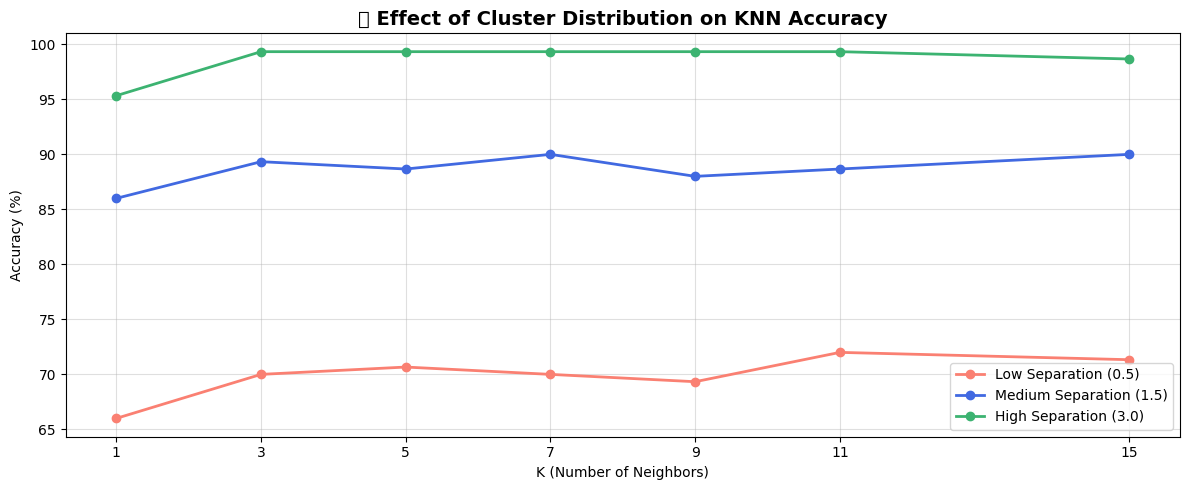

In [9]:
# ============================================================
#   SECTION 8 — How Cluster Spread Affects KNN Accuracy
#
#   class_sep parameter controls how far apart classes are:
#     • Low  separation → clusters overlap → KNN struggles
#     • High separation → clusters are distinct → KNN excels
#
#   We test 3 distributions to compare the impact.
# ============================================================

# Three levels of cluster separation to compare
sep_values   = [0.5, 1.5, 3.0]
sep_labels   = ['Low Separation (0.5)', 'Medium Separation (1.5)', 'High Separation (3.0)']
sep_colors   = ['salmon', 'royalblue', 'mediumseagreen']

# For each separation level, we test all K values
plt.figure(figsize=(12, 5))

for sep, label, color in zip(sep_values, sep_labels, sep_colors):
    # Generate dataset with this separation level
    X_t, Y_t = make_classification(
        n_samples=500, n_features=5, n_informative=4,
        n_redundant=1, n_classes=3, n_clusters_per_class=1,
        class_sep=sep, random_state=42
    )

    # Scale, split, and evaluate for each K
    X_t = StandardScaler().fit_transform(X_t)
    X_tr, X_te, Y_tr, Y_te = train_test_split(X_t, Y_t, test_size=0.3, random_state=42)

    accs = []
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_tr, Y_tr)
        accs.append(accuracy_score(Y_te, knn.predict(X_te)) * 100)

    # Plot this separation's line
    plt.plot(k_values, accs, marker='o', label=label, color=color, linewidth=2)
    print(f"{label:<30} → Best accuracy: {max(accs):.2f}% at K={k_values[np.argmax(accs)]}")

plt.title('🔬 Effect of Cluster Distribution on KNN Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Accuracy (%)')
plt.xticks(k_values)
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


---
## ✅ Section 9: Conclusion & Key Findings

### 📊 Results Summary

| Dataset | Best K | Best Accuracy | Notes |
|---------|--------|---------------|-------|
| 🌸 Iris | Varies | ~97% | Simple 3-class dataset, small K works well |
| 🩺 Breast Cancer | Varies | ~97% | High-dimensional, scaling is crucial |
| 🧪 Synthetic | Varies | ~90%+ | Depends on cluster separation |

---

### 🔑 Key Takeaways

1. **KNN is a lazy learner** — it stores all training data and only classifies at prediction time. No model is built during training.

2. **Feature scaling is essential** — KNN relies entirely on distance. Without scaling, features with large ranges unfairly dominate the distance calculation.

3. **Choosing K matters greatly:**
   - Small K (e.g., K=1) → overfits noise, jagged boundaries
   - Large K → smoother boundaries, but risks underfitting
   - **Optimal K must be found by experimentation**

4. **Cluster separation directly impacts accuracy** — when classes are well-separated, even small K values perform excellently. Overlapping clusters require larger K for smoother decision boundaries.

5. **Custom KNN matches sklearn KNN** — this confirms our implementation is mathematically correct.

---
*Lab Task 09 — Mohammad Sami (SAP: 53199) — AI — Mr. Junaid Khan*
